# New York education performance over time (NAEP)

**There is no "state IQ" dataset in this platform.** The ingestion specification (section 22) says not to
use state IQ as a variable because no clean, standardized, official state-IQ series exists, and to use
NAEP achievement scores as the education-performance proxy instead. This notebook shows the closest
honest equivalent: New York's **NAEP average scale scores** (mathematics and reading, grades 4 and 8)
for every state assessment year, from the `naep` table (source: NCES NAEP Data Service, dataset
`naep-state`).

Notes:
* Scores are on the NAEP 0–500 scale; they are *averages*, not medians (NAEP does not publish state medians).
* Each point is an assessment year; NAEP is biennial (2020 skipped because of the pandemic).
* `pct_at_or_above_proficient` is shown as a second view.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import electiondata as ed

naep = ed.read_table("naep")
ny = naep[naep["state"] == "NY"].sort_values(["subject", "grade", "assessment_year"])
ny[["assessment_year", "grade", "subject", "average_score", "pct_at_or_above_basic",
    "pct_at_or_above_proficient", "publication_date", "source"]].reset_index(drop=True)

,assessment_year,grade,subject,average_score,pct_at_or_above_basic,pct_at_or_above_proficient,publication_date,source
0,2003,4,mathematics,235.930075,0.787012,0.32893,2003-12-31,NAEP
1,2005,4,mathematics,238.173977,0.812899,0.36082,2005-12-31,NAEP
2,2007,4,mathematics,242.543018,0.850787,0.433275,2007-12-31,NAEP
3,2009,4,mathematics,240.641099,0.833288,0.401595,2010-06-30,NAEP
4,2011,4,mathematics,237.519943,0.797883,0.358668,2011-12-31,NAEP
5,2013,4,mathematics,240.349817,0.823928,0.396524,2013-12-31,NAEP
6,2015,4,mathematics,236.796927,0.788746,0.349136,2015-12-31,NAEP
7,2017,4,mathematics,235.548457,0.761091,0.35468,2018-06-30,NAEP
8,2019,4,mathematics,236.730707,0.764786,0.3694,2019-12-31,NAEP
9,2022,4,mathematics,227.090134,0.662081,0.284209,2022-12-31,NAEP


In [2]:
scores = ny.pivot_table(index="assessment_year", columns=["subject", "grade"], values="average_score")
scores.columns = [f"{s} g{g}" for s, g in scores.columns]
scores.round(1)

,mathematics g4,mathematics g8,reading g4,reading g8
assessment_year,,,,
2003,235.9,279.7,222.2,265.3
2005,238.2,279.7,222.7,265.1
2007,242.5,280.1,223.8,263.5
2009,240.6,282.6,224.4,264.3
2011,237.5,280.5,222.5,265.7
2013,240.3,281.8,223.8,266.3
2015,236.8,280.1,222.6,263.2
2017,235.5,281.7,221.9,264.2
2019,236.7,280.4,219.6,261.8


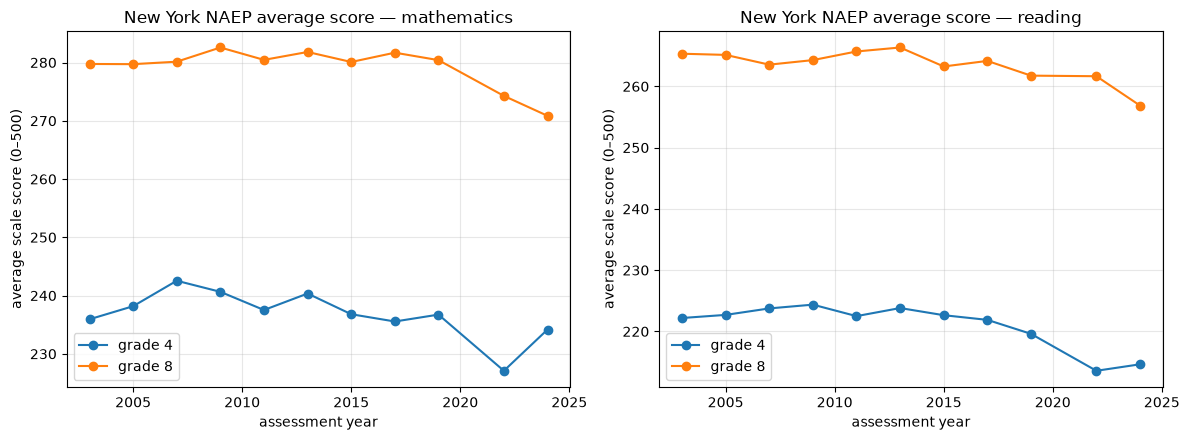

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
for ax, subject in zip(axes, ["mathematics", "reading"]):
    for grade in (4, 8):
        col = f"{subject} g{grade}"
        ax.plot(scores.index, scores[col], marker="o", label=f"grade {grade}")
    ax.set_title(f"New York NAEP average score — {subject}")
    ax.set_xlabel("assessment year")
    ax.set_ylabel("average scale score (0–500)")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

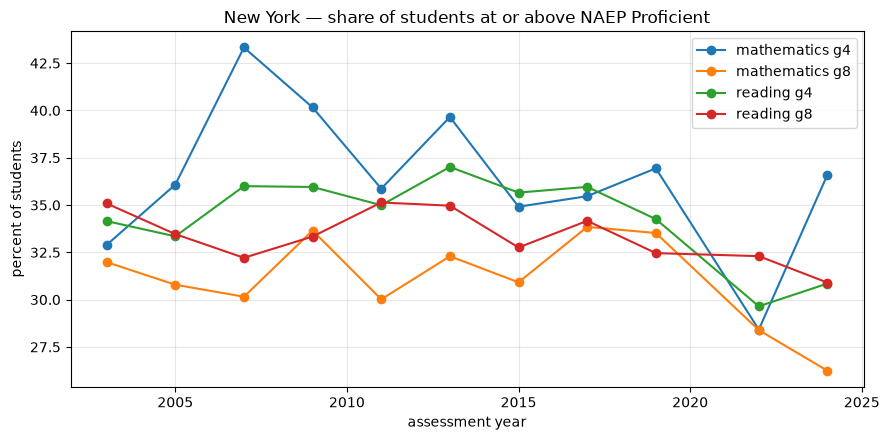

In [4]:
prof = ny.pivot_table(index="assessment_year", columns=["subject", "grade"], values="pct_at_or_above_proficient")
prof.columns = [f"{s} g{g}" for s, g in prof.columns]
ax = (prof * 100).plot(marker="o", figsize=(9, 4.5))
ax.set_title("New York — share of students at or above NAEP Proficient")
ax.set_ylabel("percent of students")
ax.set_xlabel("assessment year")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## New York versus the national state average

Same measure for context: NY's grade-8 mathematics score compared with the mean of all 50 states + DC.

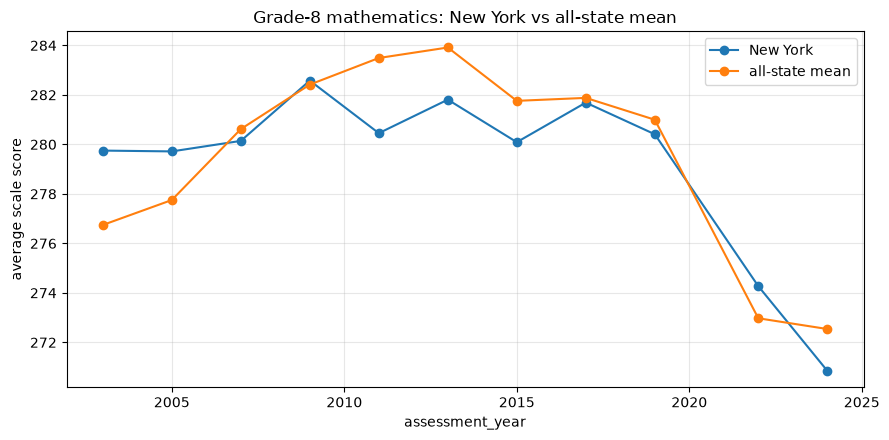

,New York,all-state mean,NY minus mean
assessment_year,,,
2003,279.7,276.7,3.0
2005,279.7,277.8,2.0
2007,280.1,280.6,-0.5
2009,282.6,282.4,0.2
2011,280.5,283.5,-3.0
2013,281.8,283.9,-2.1
2015,280.1,281.8,-1.7
2017,281.7,281.9,-0.2
2019,280.4,281.0,-0.6


In [5]:
g8 = naep[(naep["grade"] == 8) & (naep["subject"] == "mathematics")]
national_mean = g8.groupby("assessment_year")["average_score"].mean().rename("all-state mean")
ny_g8 = g8[g8["state"] == "NY"].set_index("assessment_year")["average_score"].rename("New York")
cmp = pd.concat([ny_g8, national_mean], axis=1)
cmp["NY minus mean"] = cmp["New York"] - cmp["all-state mean"]
ax = cmp[["New York", "all-state mean"]].plot(marker="o", figsize=(9, 4.5))
ax.set_title("Grade-8 mathematics: New York vs all-state mean")
ax.set_ylabel("average scale score")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
cmp.round(1)